In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\GED\PycharmProjects\Aixelo_Project_DataLab_2025\ODAC_data\45_CO2_fingerprints.csv')

In [4]:
print(df.describe())

       atomic_num_mean  atomic_num_geometric_mean  \
count      4601.000000                4601.000000   
mean          7.186315                   5.002992   
std           2.521164                   1.917063   
min           2.970874                   1.975945   
25%           5.645570                   3.767630   
50%           6.535211                   4.485482   
75%           7.923664                   5.574759   
max          34.067797                  24.976794   

       atomic_num_standard_deviation  atomic_num_max  atomic_num_min  \
count                    4601.000000     4601.000000     4601.000000   
mean                        7.245915       37.471637        1.535970   
std                         3.661421       16.049221        1.544717   
min                         1.619657        8.000000        1.000000   
25%                         4.922352       28.000000        1.000000   
50%                         6.260522       30.000000        1.000000   
75%               

In [5]:
print(df.isnull().sum())

MOF                                       0
atomic_num_mean                           0
atomic_num_geometric_mean                 0
atomic_num_standard_deviation             0
atomic_num_max                            0
atomic_num_min                            0
group_num_mean                            0
group_num_geometric_mean                  0
group_num_standard_deviation              0
group_num_max                             0
group_num_min                             0
period_num_mean                           0
period_num_geometric_mean                 0
period_num_standard_deviation             0
period_num_max                            0
period_num_min                            0
electronegativity_mean                  142
electronegativity_geometric_mean        142
electronegativity_standard_deviation    142
electronegativity_max                   142
electronegativity_min                   142
electron_affinity_mean                   60
electron_affinity_geometric_mean

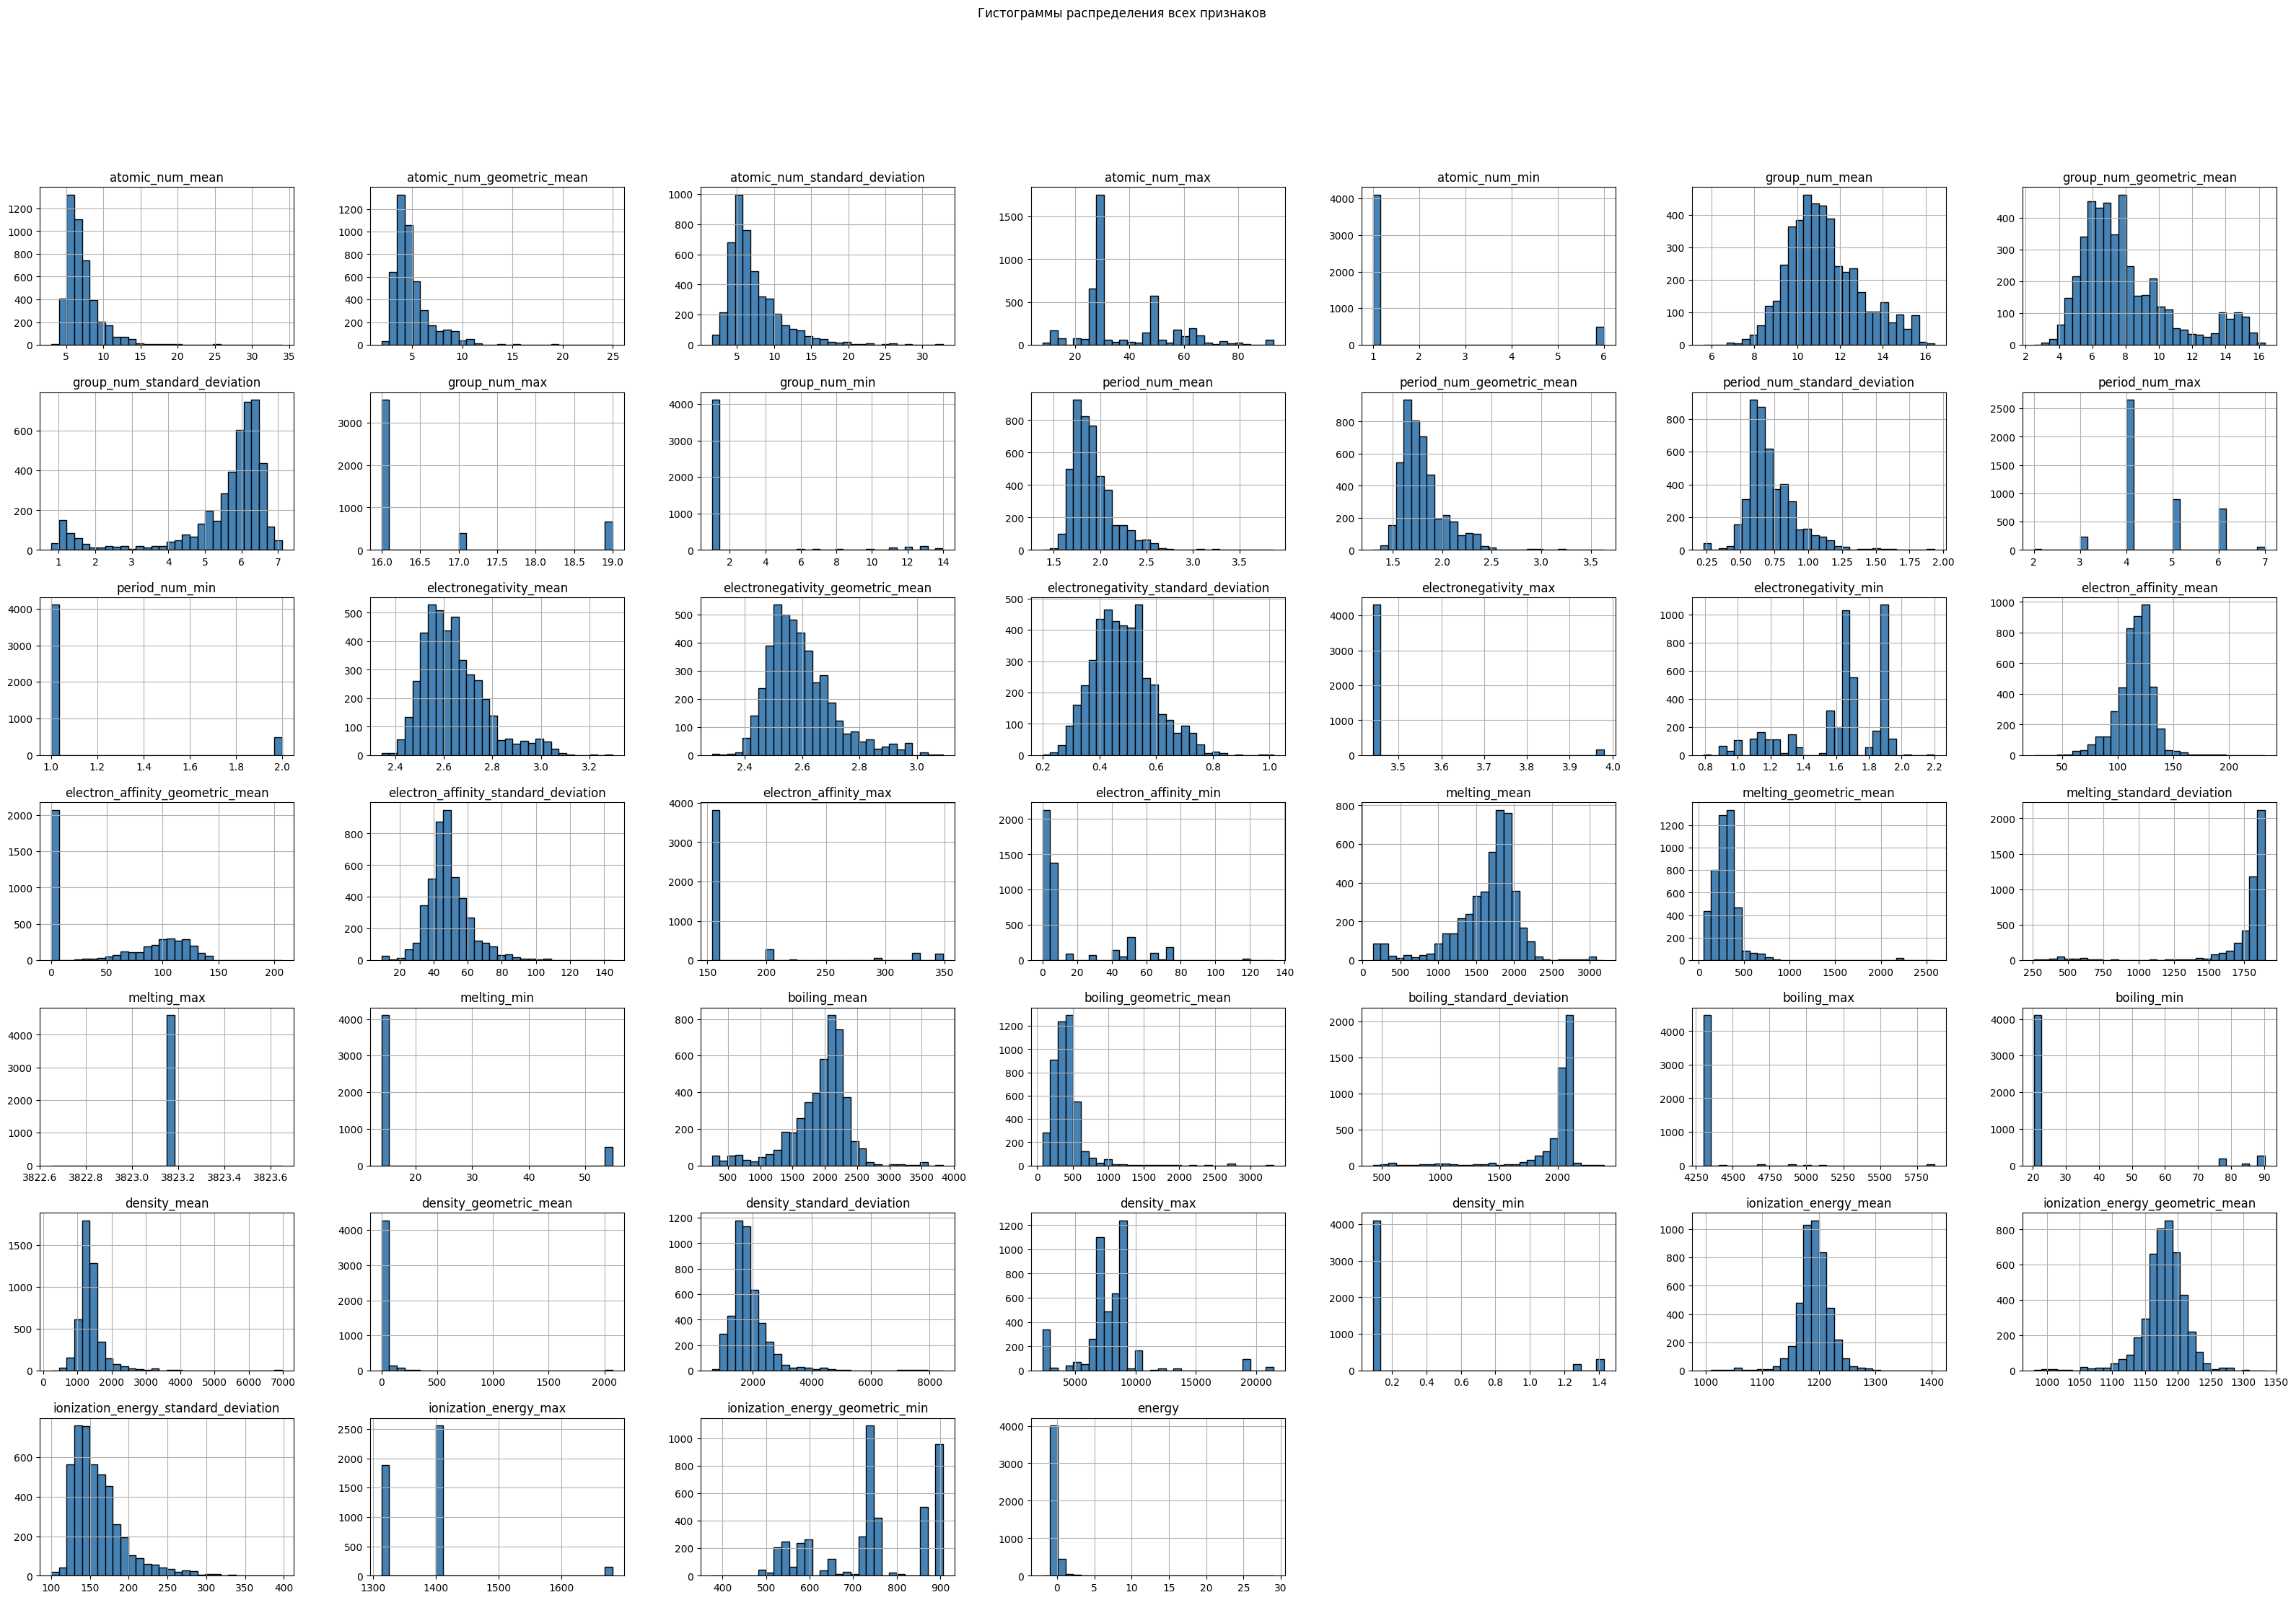

In [8]:
df.hist(bins=30, figsize=(40, 25), color='steelblue', edgecolor='black')
plt.suptitle('Histograms of the distribution of all features')
plt.show()

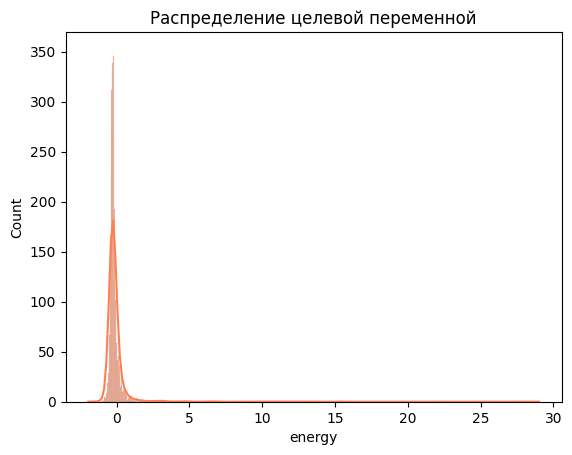

In [9]:
sns.histplot(df['energy'], kde=True, color='coral')
plt.title('Target variable distribution')
plt.show()

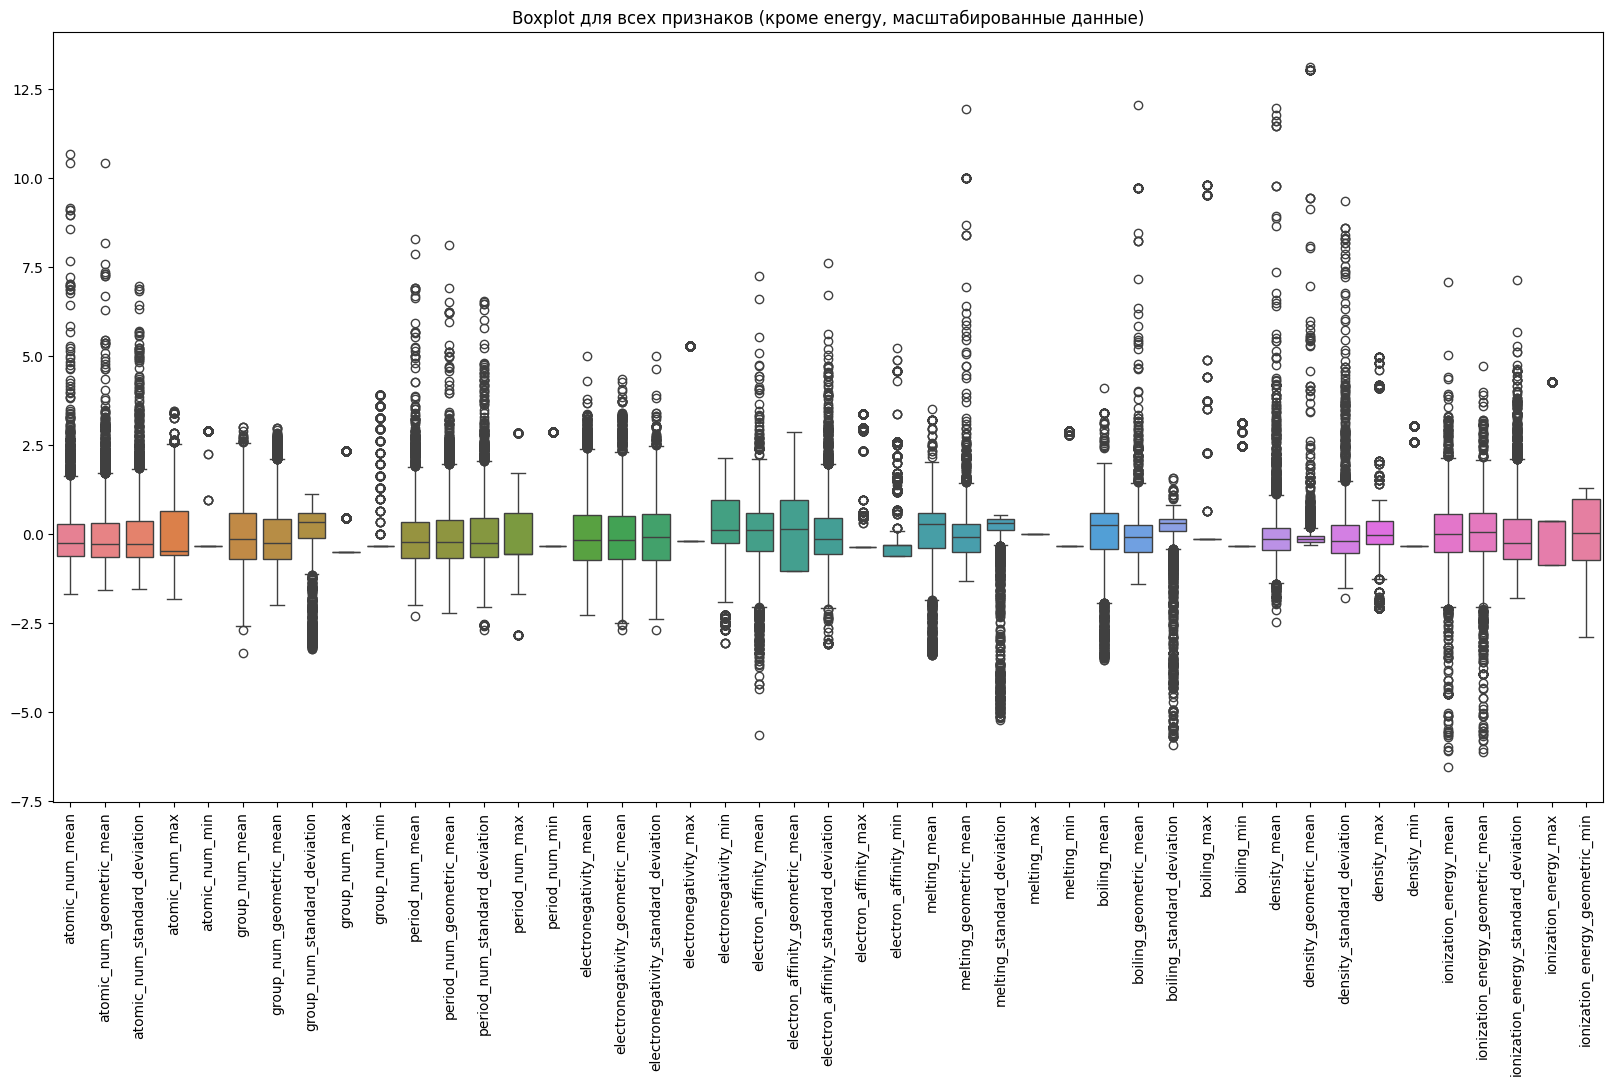

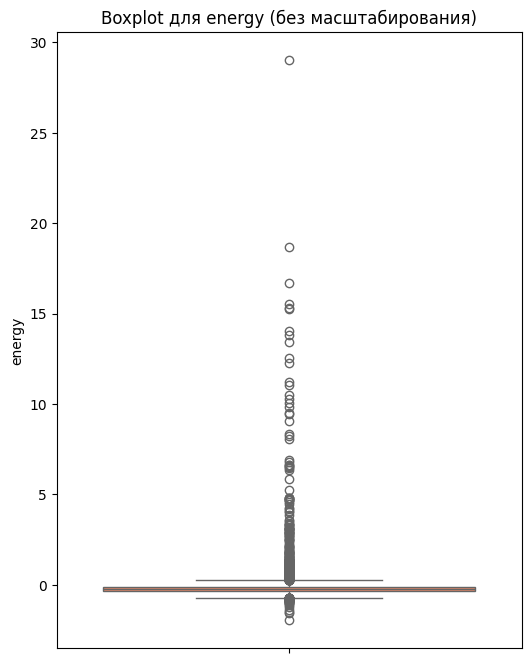

In [12]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

numeric_features = df.select_dtypes(include=np.number).drop(columns=['energy'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_features)

scaled_df = pd.DataFrame(scaled_data, columns=numeric_features.columns)

plt.figure(figsize=(20, 10))
sns.boxplot(data=scaled_df)
plt.title('Boxplot for all features (except energy, scaled data)')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(6, 8))
sns.boxplot(y=df['energy'], color='coral')
plt.title('Boxplot for energy (unscaled data)')
plt.show()


atomic_num_mean                         0.079405
atomic_num_geometric_mean               0.082358
atomic_num_standard_deviation           0.049857
atomic_num_max                          0.005985
atomic_num_min                          0.102691
group_num_mean                          0.070871
group_num_geometric_mean                0.086283
group_num_standard_deviation           -0.106375
group_num_max                          -0.008772
group_num_min                           0.098147
period_num_mean                         0.087103
period_num_geometric_mean               0.089882
period_num_standard_deviation           0.029919
period_num_max                         -0.002370
period_num_min                          0.105651
electronegativity_mean                 -0.000441
electronegativity_geometric_mean        0.000454
electronegativity_standard_deviation   -0.017134
electronegativity_max                  -0.017038
electronegativity_min                   0.005165
electron_affinity_me

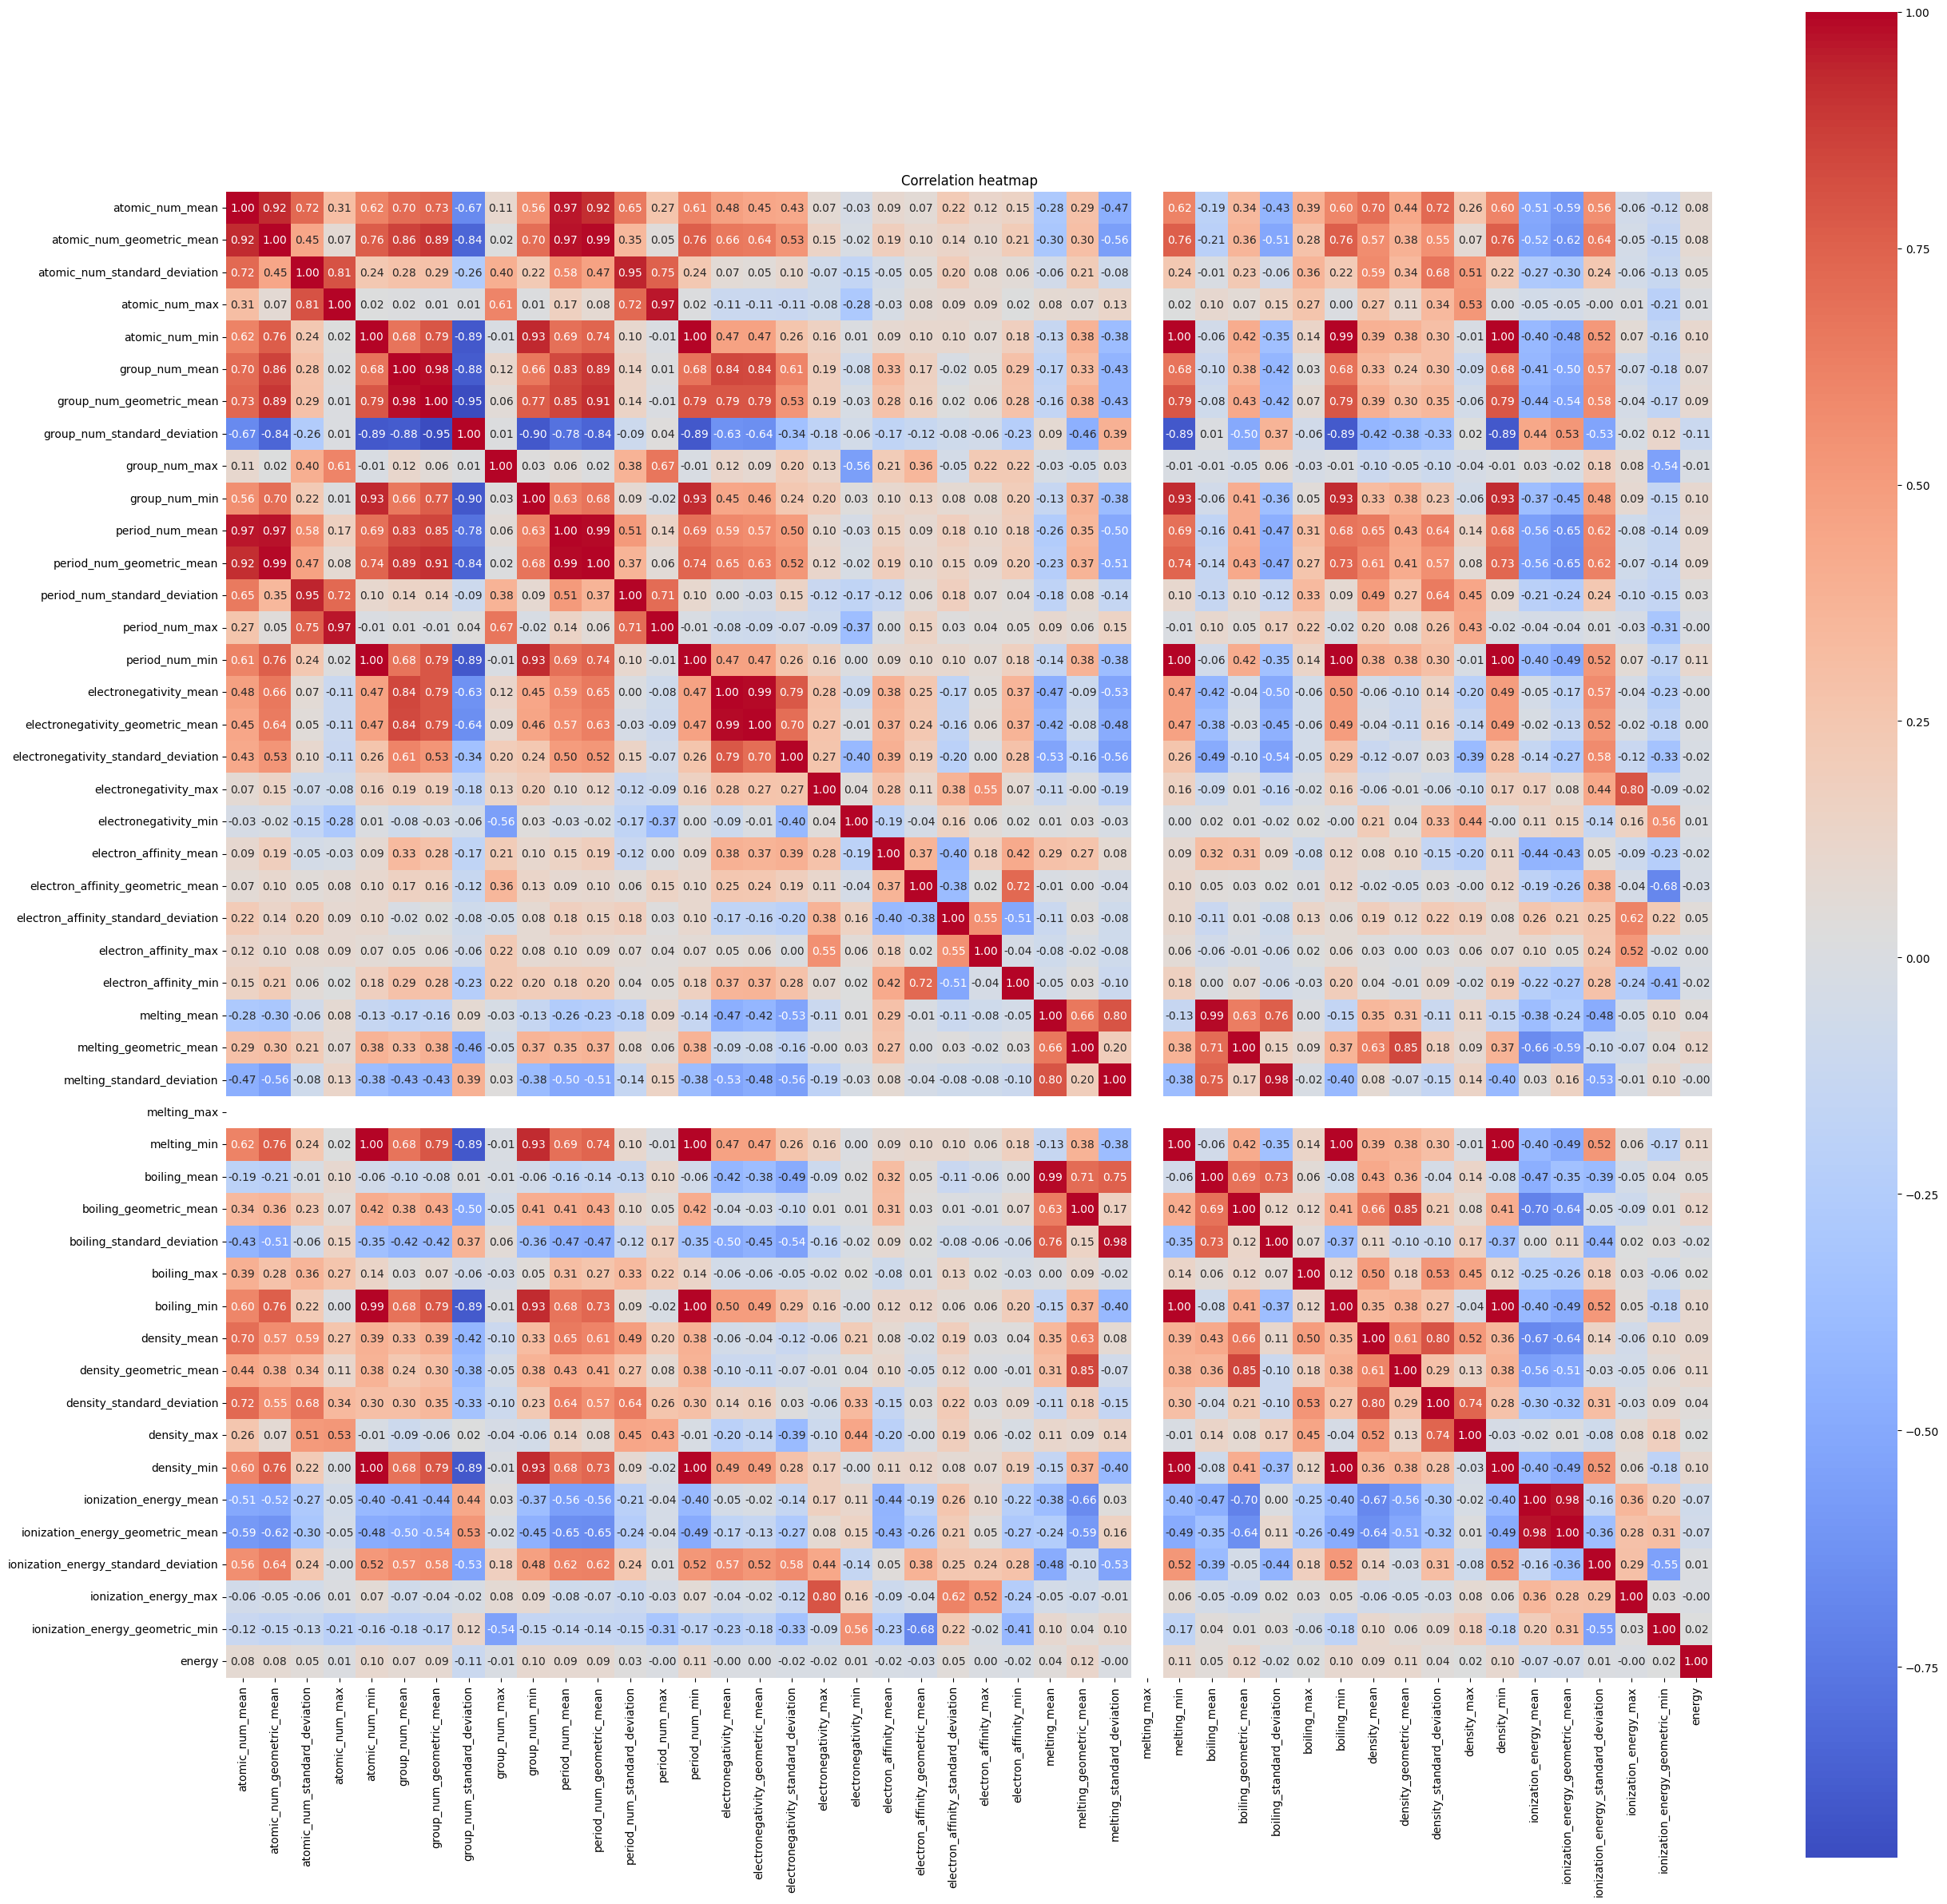

In [23]:
plot_data = df.drop('MOF', axis=1)

plt.figure(figsize=(30, 30))
corr_matrix = plot_data.corr()

print(corr_matrix['energy'])
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation heatmap')
plt.show()

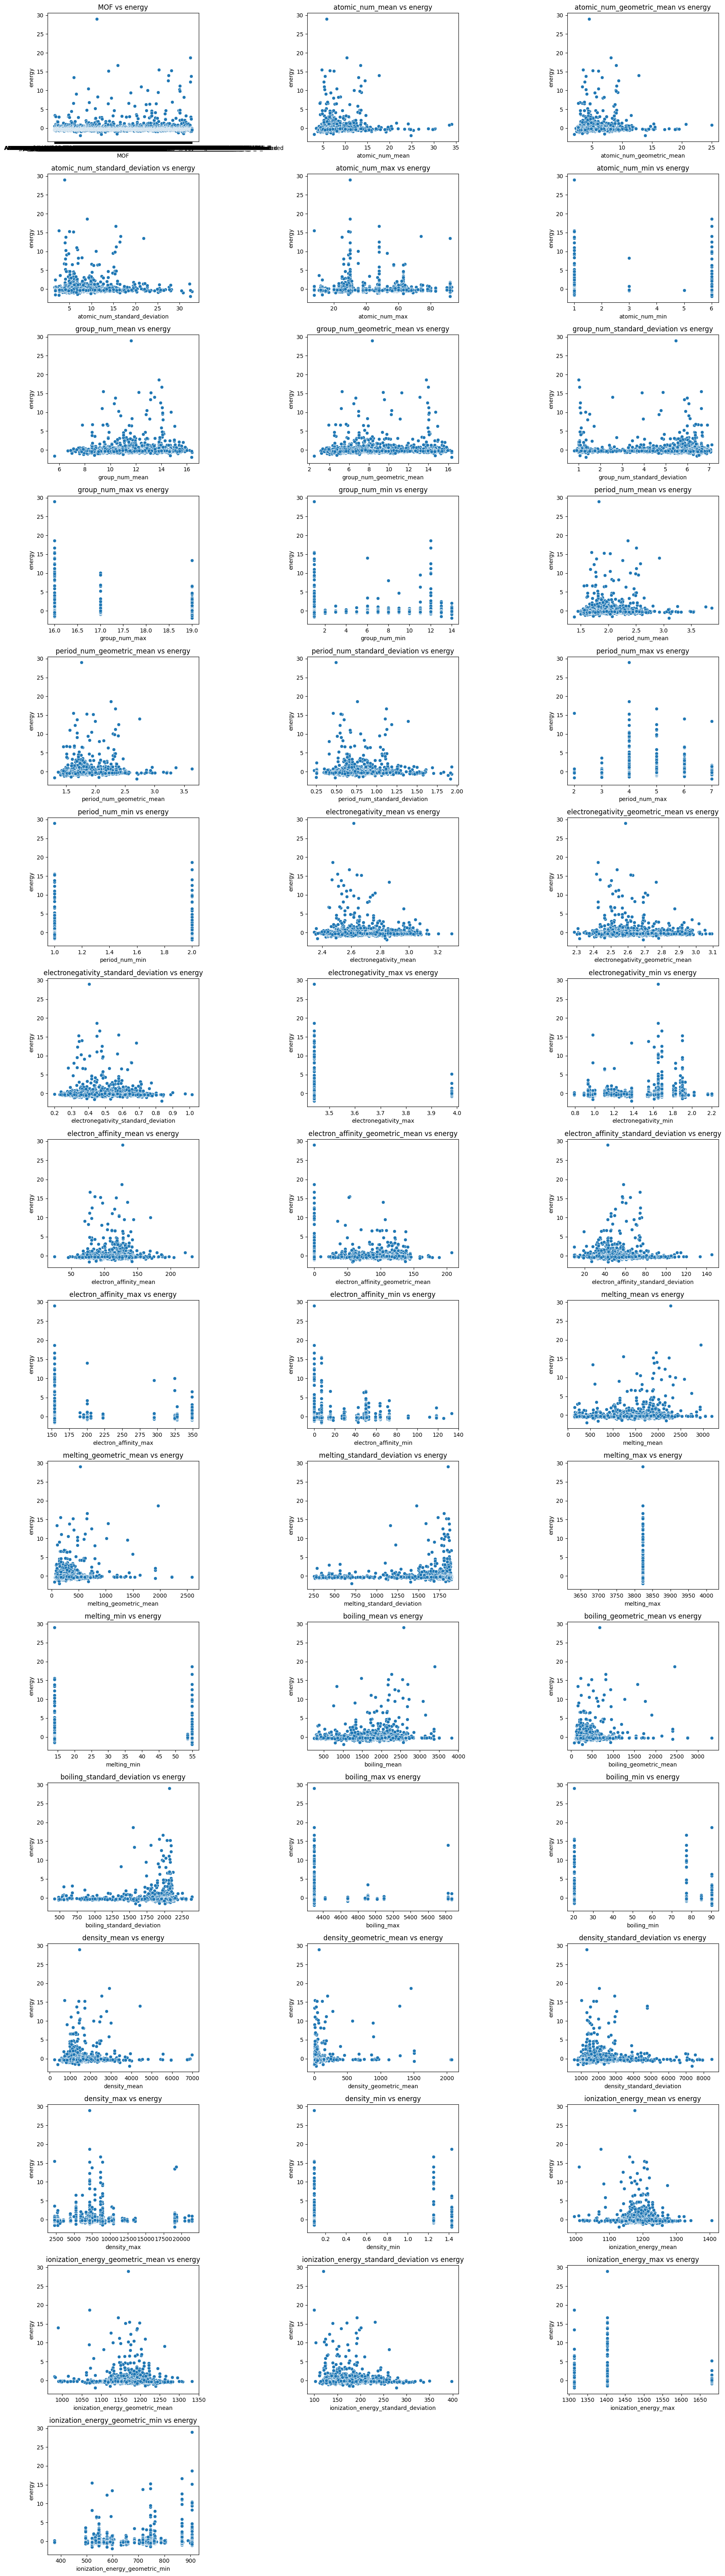

In [18]:

features = [col for col in df.columns if col != 'energy']
n_features = len(features)

cols = 3
rows = (n_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(x=df[col], y=df['energy'], ax=axes[i])
    axes[i].set_title(f'{col} vs energy')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


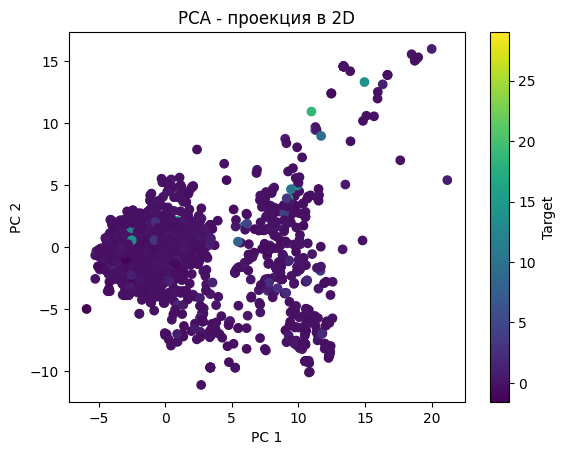

In [22]:
from sklearn.decomposition import PCA

df = df.dropna()

pca_data = df.drop(['energy', 'MOF'], axis=1)


scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)

pca = PCA(n_components=2)
components = pca.fit_transform(pca_data_scaled)

plt.scatter(components[:, 0], components[:, 1], c=df['energy'], cmap='viridis')
plt.colorbar(label='Target')
plt.title('PCA - 2D projection')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()